# 使用 RegVelo 进行 RNA velocity 和调控扰动分析

[RegVelo](https://github.com/theislab/regvelo) 是一个 gene-regulatory-informed RNA velocity 模型，目标是在单细胞层面同时建模转录调控和 RNA splicing dynamics。传统 RNA velocity 方法通常根据 unspliced/spliced RNA 的变化推断细胞状态转移，但对 TF-regulon、GRN 先验和调控扰动的利用有限；而单独的 GRN 推断又往往缺少表达动态和细胞时间的信息。RegVelo 将这两类信息放到同一个生成式动力学框架中，用先验 GRN 约束转录率，并通过耦合的 ODE 系统推断 velocity、latent time 以及调控扰动后的 vector field。

<img src="https://github.com/theislab/regvelo/blob/main/docs/_static/img/overview_fig.png?raw=true" alt="RegVelo" width="600" />

从算法流程看，RegVelo 的输入包括包含 spliced/unspliced moment layer 的 AnnData、与基因空间对齐的 prior GRN，以及 TF/regulator 列表。模型会学习基因调控网络约束下的 splicing kinetics，并把结果导出为 velocity layer、latent time、gene-level kinetic parameters 和可用于下游 CellRank 的 velocity field。进一步地，训练好的 RegVelo 模型可以进行 in silico TF regulon blockade：通过移除某个 TF 的 downstream regulatory effects 生成扰动后的 velocity field，再结合 CellRank 比较原始和扰动条件下的 fate probabilities，从而连接局部调控变化与长期细胞命运偏移。

在 OmicVerse 中，我们保留了 RegVelo 的上游模型语义，同时让结果回到 `adata` 来保持与其他方法的统一。本教程使用 adata-first 的 `ov.single.velocity(..., method="regvelo")` 完成 velocity 推断，并用 `ov.single.cellrank_fate()` 与 `ov.pl.cell_fate()` 进行 CellRank fate analysis 和可视化。示例数据沿用 RegVelo 官方 zebrafish neural crest 教程，但流程被整理为 OmicVerse 风格：显式读取示例数据、准备 RegVelo 输入、推断 velocity、绘制 streamplot、连接 CellRank fate analysis，并进行 TF 扰动模拟。

参考：RegVelo 官方[仓库](https://github.com/theislab/regvelo)与[文档](https://regvelo.readthedocs.io/en/latest/index.html)。

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
import regvelo as rgv

ov.plot_set(font_path="Arial")

%reload_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 读取 RegVelo 官方示例数据并用 OmicVerse 预处理

这里仍然沿用 RegVelo 上游 zebrafish neural crest 教程的数据，但把“示例数据读取”和“RegVelo 预处理”分开：数据加载直接使用上游 `regvelo.datasets`，OmicVerse 只负责拿到 `adata` 后的 neighbor/moment、RegVelo gene preprocessing 和 GRN 对齐。

这种写法避免在 OmicVerse 中增加额外的数据下载入口，也更接近真实项目：你可以把 `rgv.datasets.zebrafish_nc()` 换成自己的 AnnData，把 `rgv.datasets.zebrafish_grn()` 换成自己的 prior GRN；后续预处理、velocity 计算和可视化仍然走同一套 OmicVerse 流程。


In [2]:
adata = rgv.datasets.zebrafish_nc()
prior_net = rgv.datasets.zebrafish_grn()

velo_prep = ov.single.Velo(adata)
prior_grn, regulators = velo_prep.prepare_regvelo(
    prior_net,
    n_neighbors=30,
    n_pcs=50,
    moment_backend="scvelo",
    prior_orientation="regulator_by_target",
)
adata = velo_prep.adata

print(adata)
print("Available layers:", list(adata.layers.keys())[:10])
print("Prior GRN shape:", prior_grn.shape)
print("TFs retained:", len(regulators))

In Velo module, you should keep all genes' expression not normalized.
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 30
   Method: umap
   Metric: euclidean
   PCs used: 50
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 697 cells with 30 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 2.1564s                                                 │
│  Shape:    697 x 8,012 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighb

    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


AnnData object with n_obs × n_vars = 697 × 1008
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'cell_type_colors', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', 'regvelo_regulators'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity'
    obsp: 'distances', 'connectivities'
Available layers: ['ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity']
Prior GRN shape: (1008, 1008)
TFs retained: 81


## 使用 OmicVerse 准备好的 prior GRN

`Velo.prepare_regvelo()` 会把对齐后的 prior network 写入 `adata.uns["skeleton"]`，并把保留下来的 regulator 列表写入 `adata.uns["regvelo_regulators"]`。RegVelo zebrafish helper 读取的上游 prior 是 regulator-by-target 方向；OmicVerse 会保存对齐后的 `adata.uns["skeleton"]`，并由 `ov.single.velocity(..., method="regvelo")` 处理 `REGVELOVI` 需要的方向。


In [3]:
prior_grn = adata.uns["skeleton"]
regulators = adata.uns["regvelo_regulators"]

print("Prior GRN shape:", prior_grn.shape)
print("Regulators:", len(regulators))

Prior GRN shape: (1008, 1008)
Regulators: 81


## 通过 `ov.single.velocity` 运行 RegVelo

RegVelo 分支现在可以作为 adata-first velocity 流程使用：训练上游模型，把 `layers["velocity"]` 导出到 `layers["velo_regvelo"]`，可选地直接构建 velocity graph、投影到 UMAP，在 `adata.uns["regvelo"]` 记录参数，并保留模型路径供后续扰动分析使用。


In [4]:
adata = ov.single.velocity(
    adata,
    method="regvelo",
    prior_grn=prior_grn,
    regulators=regulators,
    model_save_path="result/regvelo_zebrafish",
    model_overwrite=True,
    velocity_key="velo_regvelo",
    spliced_layer="Ms",
    unspliced_layer="Mu",
    n_samples=30,
    regvelo_kwargs={
        "soft_constraint": False,
    },
    train_kwargs={
        "max_epochs": 50,  # 测试中使用较小 epochs，请根据真实数据调整
    },
    compute_velocity_graph=True,
    compute_velocity_embedding=True,
    basis="umap",
    graph_kwargs={
        "xkey": "Ms",
    },
)

GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In Velo module, you should keep all genes' expression not normalized.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


computing velocity graph (using 1/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velo_regvelo_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_regvelo_umap', embedded velocity vectors (adata.obsm)


## 可视化 RegVelo vector field

这里直接使用 OmicVerse 绘图函数从 `adata` 读取结果。`ov.pl.embedding()` 绘制细胞嵌入，`ov.pl.add_streamplot()` 叠加 `adata.obsm["velo_regvelo_umap"]` 中的 velocity field。


In [5]:
adata.uns["regvelo"]

{'spliced_layer': 'Ms',
 'unspliced_layer': 'Mu',
 'n_samples': 30,
 'batch_size': 697,
 'velocity_key': 'velo_regvelo',
 'n_regulators': 81,
 'model_load_path': None,
 'model_save_path': 'result/regvelo_zebrafish',
 'model_overwrite': True,
 'reuse_regvelo_output': False,
 'reused_regvelo_output': False}

Text(0.5, 1.0, 'Velocity: RegVelo')

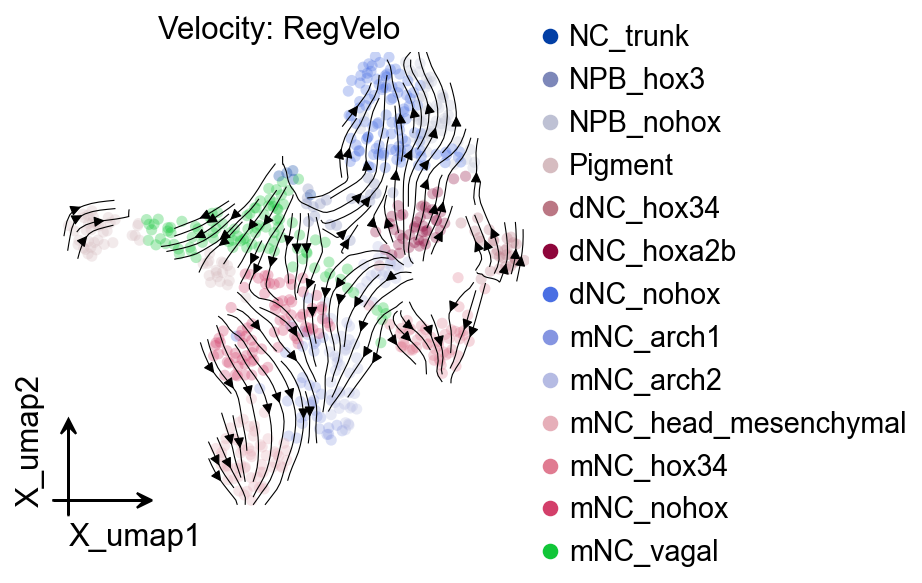

In [6]:
fig = ov.plt.figure(figsize=(4, 4))
ax = ov.plt.subplot(1, 1, 1)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=ax,
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=ax,
)
ov.plt.title("Velocity: RegVelo")

## 检查 latent time 和 regulon size

检查 latent time 和 GRN 结构。不同 RegVelo 版本导出的对象可能略有差异，因此这里先检查是否存在 `fit_t`，再绘制 latent time；同时从 `adata.uns["skeleton"]` 汇总 prior regulon 大小。

[<Axes: title={'center': 'cell_type'}, xlabel='X_umap1', ylabel='X_umap2'>,
 <Axes: title={'center': 'stage'}, xlabel='X_umap1', ylabel='X_umap2'>,
 <Axes: title={'center': 'regvelo_latent_time'}, xlabel='X_umap1', ylabel='X_umap2'>]

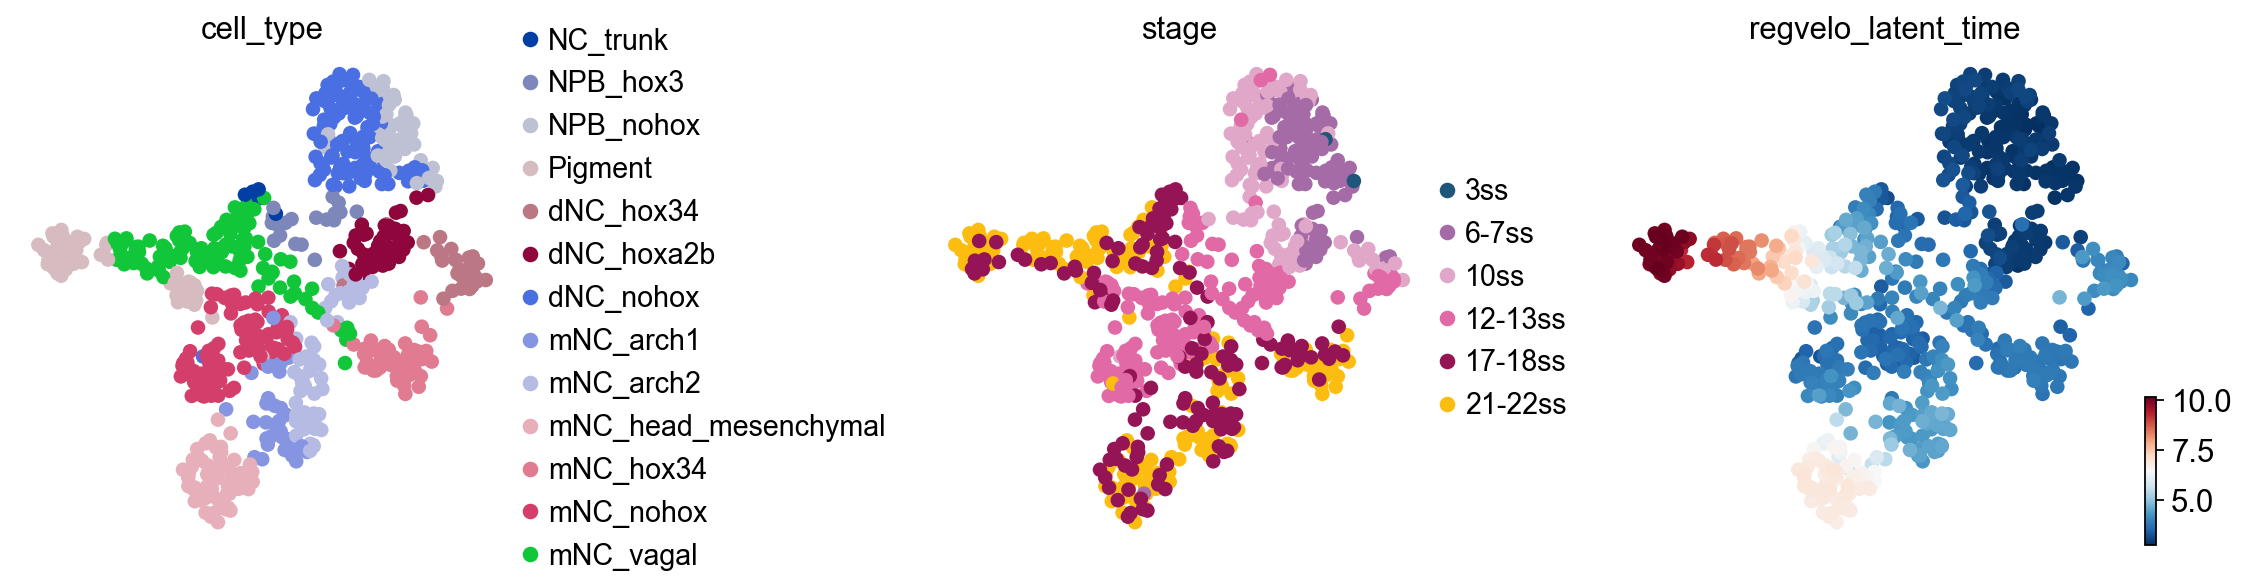

In [7]:
fit_t = np.asarray(adata.layers["fit_t"])
adata.obs["regvelo_latent_time"] = fit_t.mean(axis=1)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=["cell_type", "stage", "regvelo_latent_time"],
    ncols=3,
    frameon=False,
    show=False,
)

Text(0.5, 1.0, 'Top prior regulons')

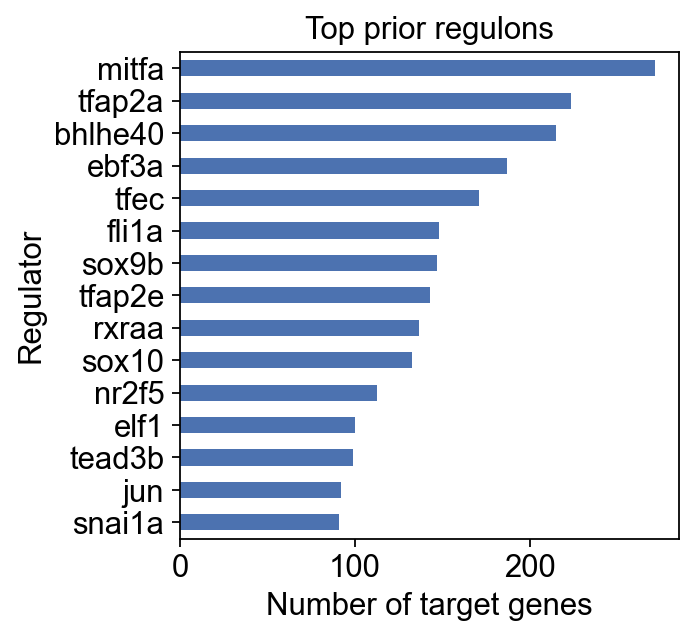

In [8]:
regulon_size = (prior_grn != 0).sum(axis=1).sort_values(ascending=False).head(15)
ax = regulon_size.sort_values().plot.barh(figsize=(4, 4), color="#4c72b0")
ax.set_xlabel("Number of target genes")
ax.set_ylabel("Regulator")
ax.set_title("Top prior regulons")

## 基于 RegVelo velocity 的 CellRank fate analysis

`ov.single.cellrank_fate()` 会从 `adata.layers["velo_regvelo"]` 构建 CellRank velocity kernel，可选混入 connectivity kernel，计算 GPCCA macrostates，并把 estimator/kernel 保存到 `adata.uns["velocity_cellrank"]`。后续可直接用 `ov.pl.cell_fate(adata, ...)` 可视化，不需要依赖 wrapper 对象。


In [9]:
terminal_states = ["mNC_head_mesenchymal", "mNC_hox34", "Pigment"]
terminal_states = [state for state in terminal_states if state in set(adata.obs["cell_type"])]
if not terminal_states:
    raise ValueError("None of the tutorial terminal states were found in adata.obs['cell_type'].")

estimator = ov.single.cellrank_fate(
    adata,
    velocity_key="velo_regvelo",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=terminal_states,
    n_states=7,
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    plot=False,
)


In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

Defaulting to `'gmres'` solver.


  0%|          | 0/3 [00:00<?, ?/s]

`ov.pl.cell_fate()` 会复用 `adata.uns["velocity_cellrank"]["estimator"]` 中保存的 CellRank 结果。它只负责可视化，不会重新计算 terminal states。


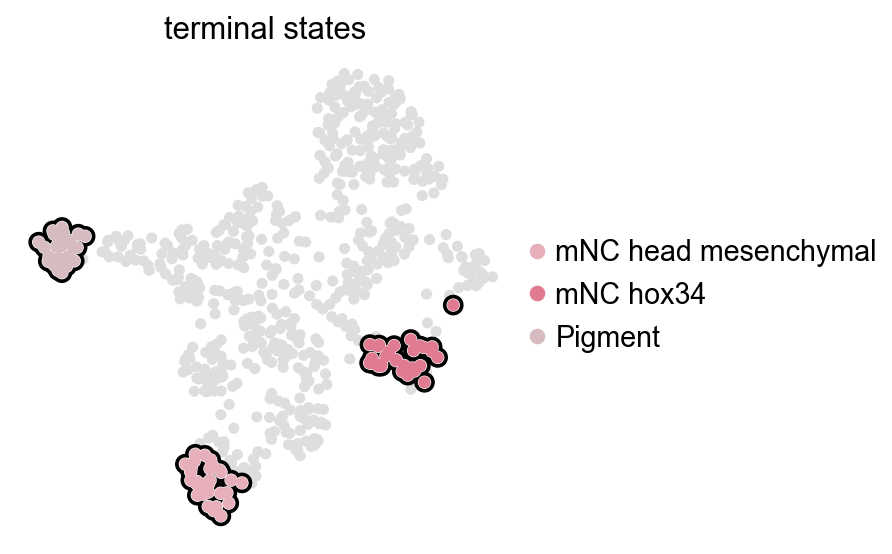

In [10]:
ov.pl.cell_fate(adata, which="terminal", basis="umap")

## fate probabilities 与 commitment score

除了 terminal state 点图，RegVelo 官方扰动教程还会查看 CellRank 的 fate probabilities 和 commitment score。`commitment_score` 基于 fate probability distribution 的 entropy；数值越低通常表示细胞命运越 committed。


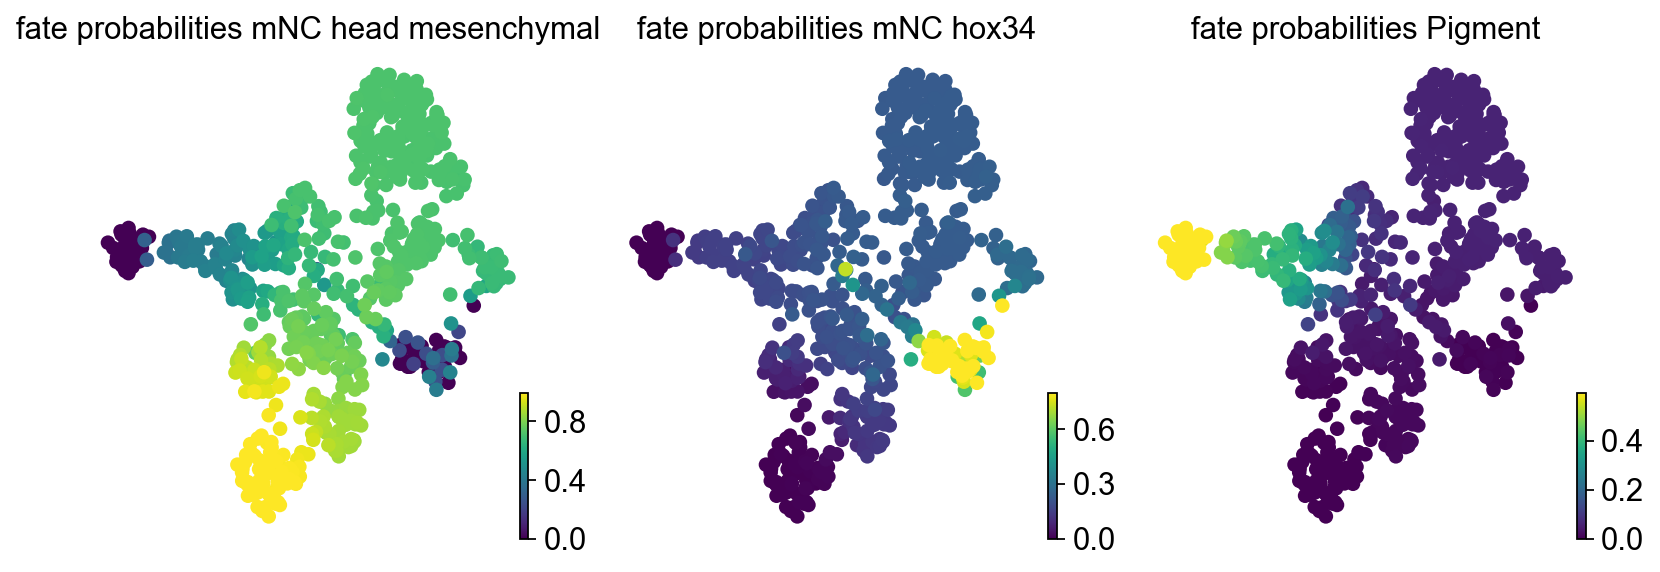

In [11]:
estimator.plot_fate_probabilities(
    same_plot=False,
    basis="umap",
)

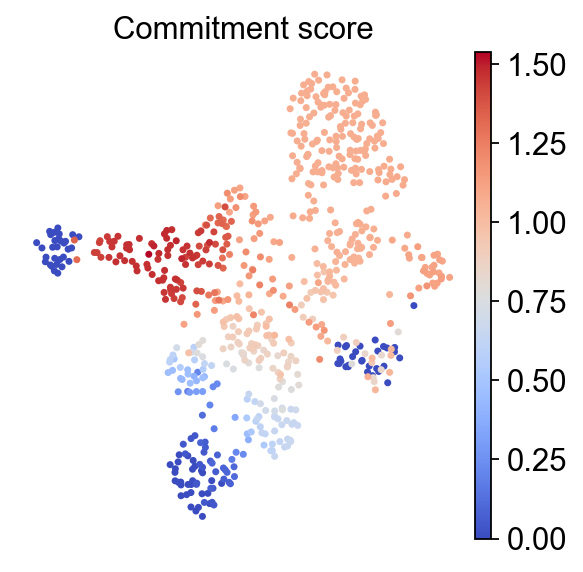

In [12]:
rgv.pl.commitment_score(
    adata=adata,
    lineage_key="lineages_fwd",
    frameon=False,
    s=40,
    cmap="coolwarm",
    title="Commitment score",
)

## RegVelo 原生 TF regulon 阻断模拟

复现仓库会使用保存的 RegVelo model 做 TF perturbation 和 regulatory screening。由于 `ov.single.velocity(method="regvelo")` 已经把模型路径记录到 `adata.uns["regvelo_model_path"]`，这里临时构建一个轻量 `Velo` helper 来继续调用 RegVelo 原生扰动 API。


In [13]:
velo_helper = ov.single.Velo(adata)
elf1_perturbed_adata, elf1_perturbed_model = velo_helper.regvelo_perturb(
    "elf1",
    model="result/regvelo_zebrafish",
    cutoff=0.001,
    batch_size=adata.n_obs,
)

print(elf1_perturbed_adata)

In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_zebrafish/model.pt already downloaded                                                 


AnnData object with n_obs × n_vars = 697 × 1008
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage', 'velo_regvelo_self_transition', 'regvelo_latent_time', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'commitment_score'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_beta', 'fit_gamma', 'fit_scaling', 'velo_regvelo_genes'
    uns: 'cell_type_colors', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', 'regvelo_regulators', '_scvi_uuid', '_scvi_manager_uuid', 'regvelo_model_path', 'regvelo', 'velo_regvelo_graph', 'velo_regvelo_graph_neg', 'velo_regvelo_params', 'stage_colors_rgba', 'stage_colors', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_

In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 8/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


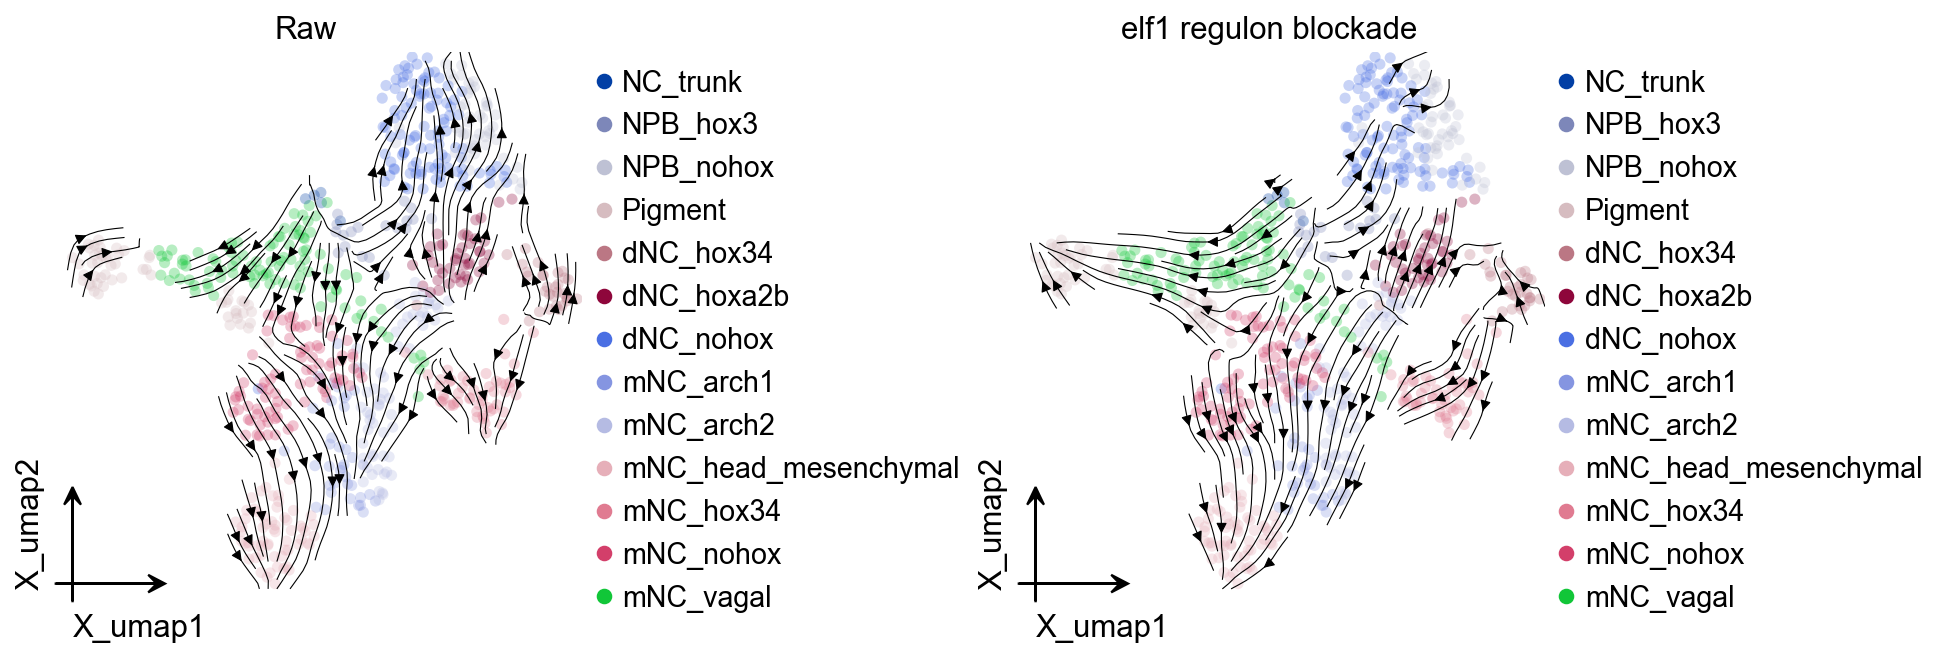

In [14]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[0],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=axes[0],
)
axes[0].set_title("Raw")

elf1_perturbed_velo = ov.single.Velo(elf1_perturbed_adata)
elf1_perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=8)
elf1_perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")

ov.pl.embedding(
    elf1_perturbed_adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[1],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    elf1_perturbed_adata,
    basis="X_umap",
    velocity_key="velocity_umap",
    ax=axes[1],
)
axes[1].set_title("elf1 regulon blockade")

ov.plt.show()

## 量化 TF blockade 的影响

除了 streamplot 可视化，还可以进一步比较扰动前后的 velocity field 和 CellRank fate probabilities。
这里给出两个互补指标：
- 局部效应：每个 cell 的 velocity cosine dissimilarity，数值越大表示扰动后方向改变越明显。
- 命运效应：重新用扰动后的 velocity field 计算 CellRank fate probabilities，再比较 terminal fate probability 的增加或降低。

In [15]:
ov.single.velocity_effect(
    adata,
    elf1_perturbed_adata,
    baseline_velocity_key="velo_regvelo",
    perturbed_velocity_key="velocity",
    target="elf1",
)

velocity_effect_summary = (
    adata.obs.groupby("cell_type", observed=True)["elf1_velocity_effect"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
velocity_effect_summary


In Velo module, you should keep all genes' expression not normalized.


                          mean    median       max
cell_type                                         
Pigment               0.000225  0.000252  0.000334
NPB_hox3              0.000189  0.000152  0.000511
NC_trunk              0.000176  0.000148  0.000277
mNC_vagal             0.000152  0.000144  0.000268
mNC_arch1             0.000149  0.000132  0.000468
dNC_hox34             0.000136  0.000111  0.000351
mNC_arch2             0.000130  0.000114  0.000432
mNC_nohox             0.000121  0.000106  0.000414
mNC_hox34             0.000120  0.000109  0.000314
mNC_head_mesenchymal  0.000109  0.000097  0.000223
dNC_nohox             0.000107  0.000099  0.000226
dNC_hoxa2b            0.000105  0.000101  0.000165
NPB_nohox             0.000100  0.000091  0.000203

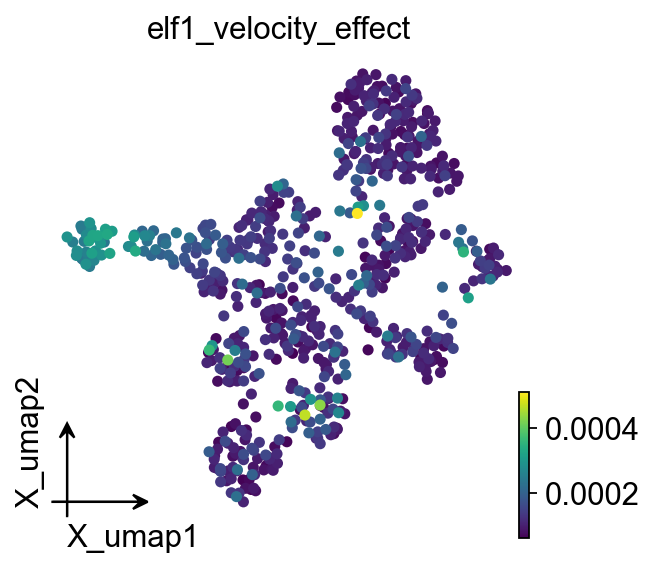

In [16]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color="elf1_velocity_effect",
    cmap="viridis",
    size=100,
)

In [17]:
elf1_estimator = ov.single.cellrank_fate(
    elf1_perturbed_adata,
    velocity_key="velocity",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=terminal_states,
    n_states=7,
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    plot=False,
)

In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/3 [00:00<?, ?/s]

In [18]:
import pandas as pd

def _lineage_to_df(adata_obj, key="lineages_fwd"):
    lineages = adata_obj.obsm[key]
    values = np.asarray(lineages)
    names = getattr(lineages, "names", None)
    if names is None:
        names = [f"lineage_{i}" for i in range(values.shape[1])]
    return pd.DataFrame(values, index=adata_obj.obs_names, columns=list(names))

baseline_fate = _lineage_to_df(adata)
elf1_fate = _lineage_to_df(elf1_perturbed_adata)
common_fates = baseline_fate.columns.intersection(elf1_fate.columns)

elf1_fate_delta = elf1_fate[common_fates] - baseline_fate[common_fates]
elf1_fate_delta.columns = [f"elf1_delta_{state}" for state in common_fates]
adata.obs = adata.obs.join(elf1_fate_delta)

elf1_fate_delta_summary = elf1_fate_delta.groupby(adata.obs["cell_type"], observed=True).mean()
elf1_fate_delta_summary

                      elf1_delta_mNC_head_mesenchymal  elf1_delta_mNC_hox34  \
cell_type                                                                     
NC_trunk                                    -0.459529             -0.127518   
NPB_hox3                                    -0.367804             -0.070306   
NPB_nohox                                   -0.298640             -0.044843   
Pigment                                     -0.203943             -0.072228   
dNC_hox34                                   -0.263292             -0.030998   
dNC_hoxa2b                                  -0.283801             -0.043709   
dNC_nohox                                   -0.296808             -0.044384   
mNC_arch1                                    0.074196             -0.105023   
mNC_arch2                                    0.026702             -0.107880   
mNC_head_mesenchymal                         0.003305             -0.003480   
mNC_hox34                                    0.03440

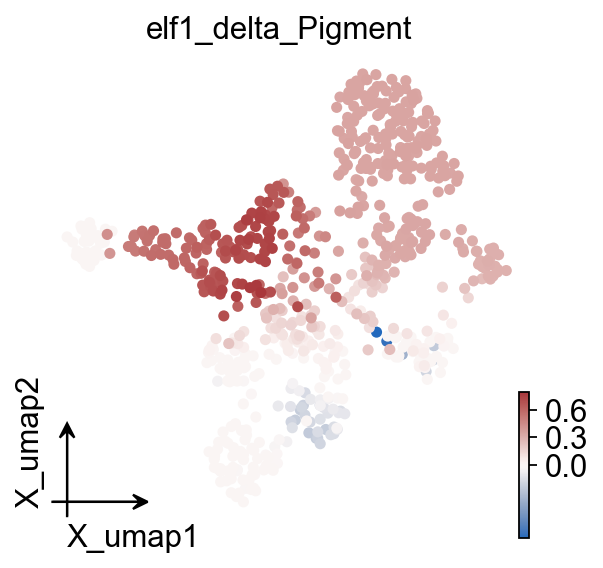

In [19]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color="elf1_delta_Pigment",
    cmap="vlag",
    vcenter=0,
    size=100,
)

RegVelo 也提供原生的 fate perturbation 统计函数，用于把扰动后的 fate probability depletion/enrichment 汇总成表。这里通过 `ov.single.cell_fate_perturbation()` 统一调用，OmicVerse 会在内部兼容不同 RegVelo 版本中的 `metrics` / `mt` 路径。


In [20]:
elf1_fate_stats = ov.single.cell_fate_perturbation(
    adata,
    perturbed={"elf1": elf1_perturbed_adata},
    terminal_states=terminal_states,
    score_method="likelihood",
)
elf1_fate_stats


In Velo module, you should keep all genes' expression not normalized.


   Depletion likelihood       p-value  FDR adjusted p-value  \
0              0.661134  1.041763e-25          1.562645e-25   
1              0.698439  5.703815e-38          1.711145e-37   
2              0.295141  1.000000e+00          1.000000e+00   

         Terminal state    TF  
0  mNC_head_mesenchymal  elf1  
1             mNC_hox34  elf1  
2               Pigment  elf1  

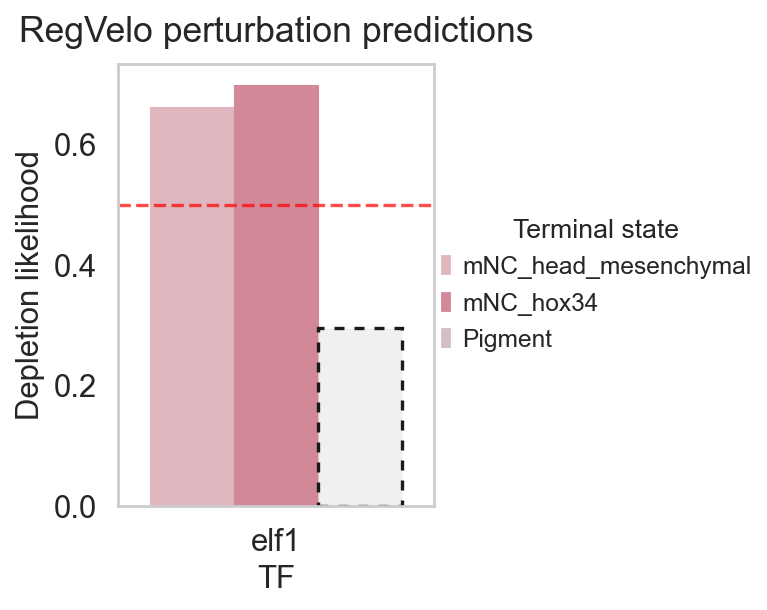

In [21]:
rgv.pl.cellfate_perturbation(
    adata=adata,
    df=elf1_fate_stats,
    color_label="cell_type",
    figsize=(5, 4),
)

## Single-cell perturbation effect

`ov.single.perturbation_effect()` 用于把扰动前后的 fate probability 差异写回 `adata.obs`。负值表示该 cell 朝某个 terminal fate 的 probability 降低，正值表示升高。


In [22]:
adata = ov.single.perturbation_effect(
    adata,
    elf1_perturbed_adata,
    terminal_states=terminal_states,
)

effect_cols = [col for col in adata.obs.columns if col.startswith("perturbation effect on ")]
print(effect_cols)


In Velo module, you should keep all genes' expression not normalized.
['perturbation effect on mNC_head_mesenchymal', 'perturbation effect on mNC_hox34', 'perturbation effect on Pigment']


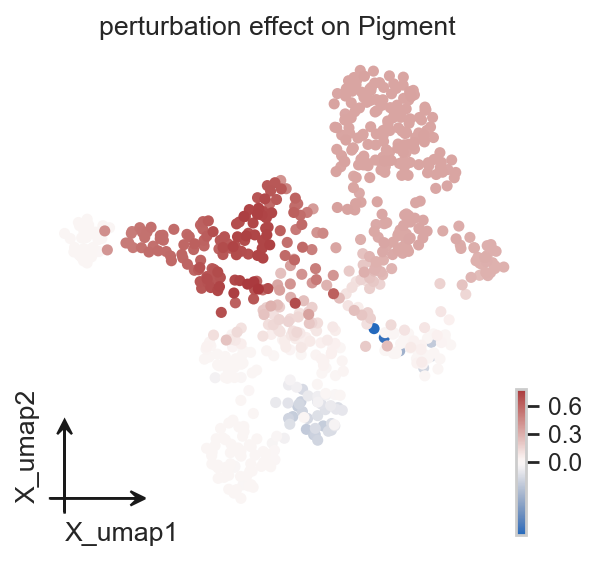

In [23]:
effect_key = "perturbation effect on Pigment"
ov.pl.embedding(
    adata,
    basis="X_umap",
    color=effect_key,
    cmap="vlag",
    vcenter=0,
    size=100,
)

## 多个 TF 同时 blockade

`regvelo_perturb()` 的 `tf` 参数也可以传入多个 TF。多 TF 组合扰动通常用于探索协同调控，但建议先确认这些 TF 都在当前模型保留的 regulator 列表中。

In [24]:
multi_tfs = ["elf1", "nr2f5"]
multi_tfs = [tf for tf in multi_tfs if tf in adata.var_names]

multi_perturbed_adata, multi_perturbed_model = ov.single.Velo(adata).regvelo_perturb(
    multi_tfs,
    model="result/regvelo_zebrafish",
    cutoff=0.001,
    batch_size=adata.n_obs,
)

multi_perturbed_velo = ov.single.Velo(multi_perturbed_adata)
multi_perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=8)
multi_perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")

In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_zebrafish/model.pt already downloaded                                                 


In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 8/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


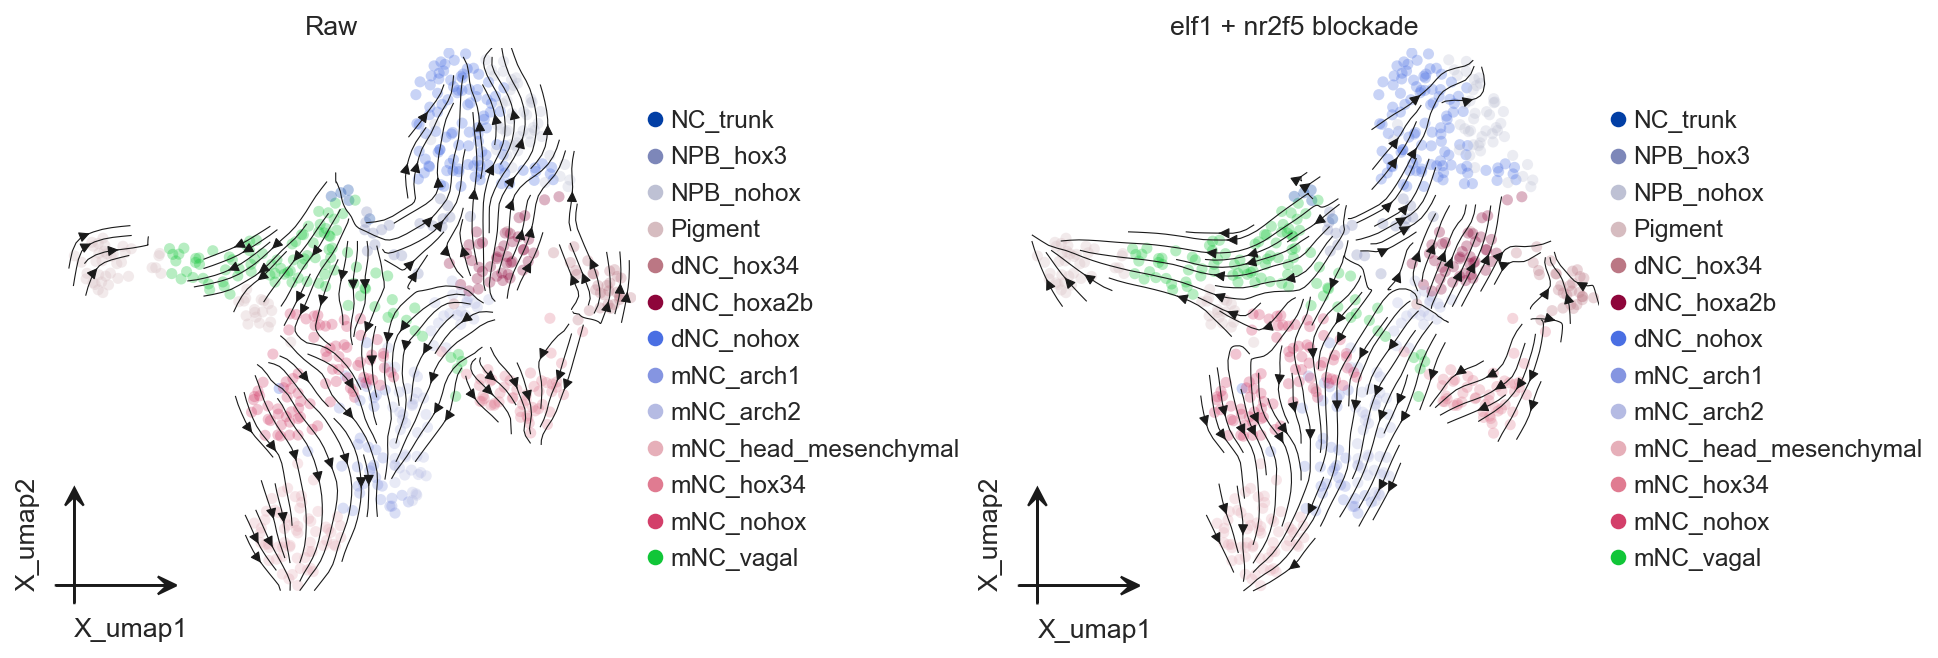

In [25]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[0],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=axes[0],
)
axes[0].set_title("Raw")

ov.pl.embedding(
    multi_perturbed_adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[1],
    show=False,
    size=100,
    alpha=0.3,
)
ov.pl.add_streamplot(
    multi_perturbed_adata,
    basis="X_umap",
    velocity_key="velocity_umap",
    ax=axes[1],
)
axes[1].set_title("elf1 + nr2f5 blockade")

ov.plt.show()